In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("netflix_titles.csv")

In [4]:
# Display basic info
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Check for missing values and duplicates
display(df.isnull().sum())
display(f"Duplicate Entries: {df.duplicated().sum()}")

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

'Duplicate Entries: 0'

In [6]:
# Handle missing values
df.update(df[['director', 'cast', 'country', 'date_added']].fillna('Unknown'))
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [7]:
# Handling duration
df['duration'] = df['duration'].fillna('0 min')
df['duration_num'] = df['duration'].str.extract('(\\d+)').astype(float)

In [8]:
# Descriptive statistics
display(df[['release_year', 'duration_num']].describe())

,release_year,duration_num
count,8807.000000,8807.000000
mean,2014.180198,69.823095
std,8.819312,50.822520
min,1925.000000,0.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


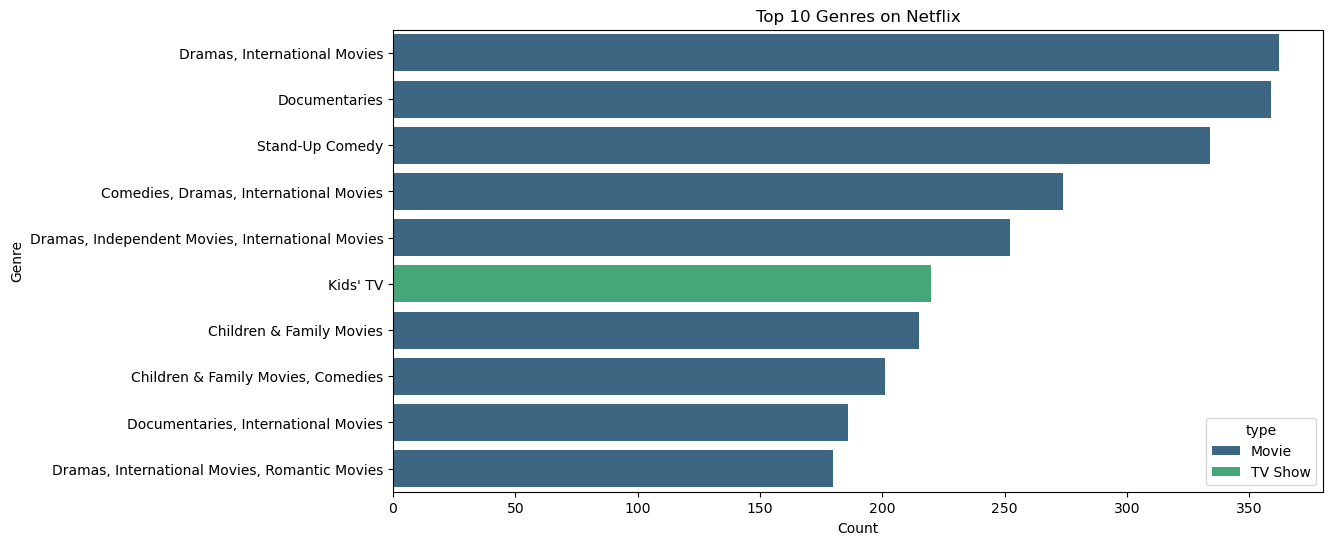

In [9]:
# Visualization - Genre distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=df['listed_in'].explode(), order=df['listed_in'].explode().value_counts().index[:10], hue=df['type'], palette='viridis')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

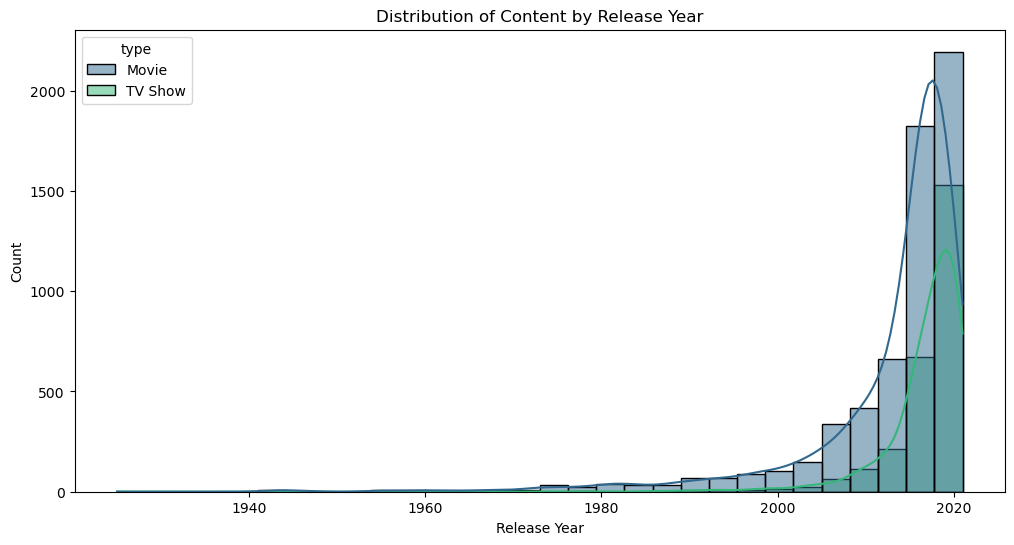

In [10]:
# Visualization - Release Year Distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', bins=30, kde=True, hue='type', palette='viridis')
plt.title("Distribution of Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

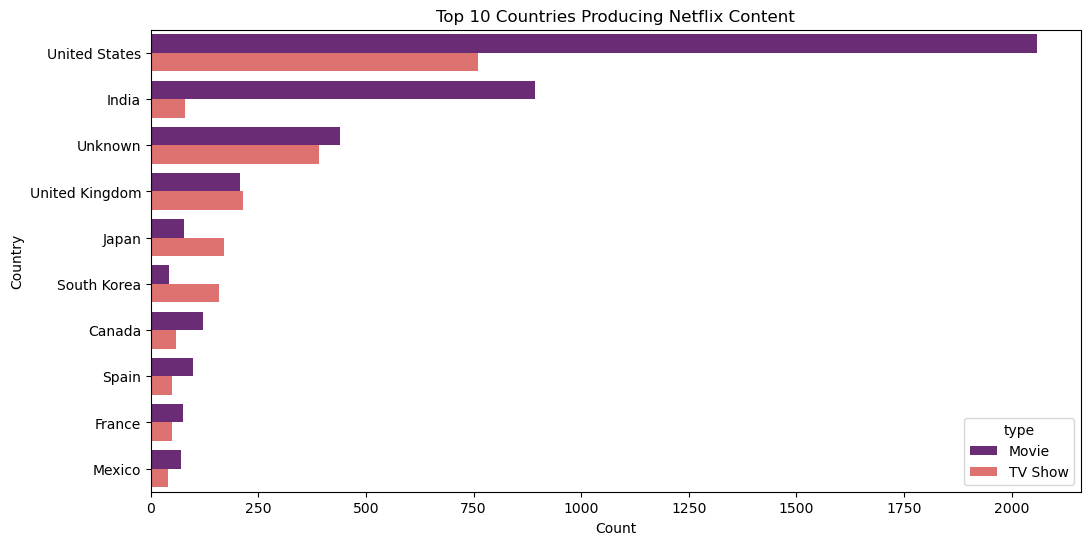

In [11]:
# Visualization - Country Distribution
plt.figure(figsize=(12, 6))
sns.countplot(y=df['country'], order=df['country'].value_counts().index[:10], hue=df['type'], palette='magma')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

In [12]:
# Content Analysis - Ratings
display(df['rating'].value_counts())

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

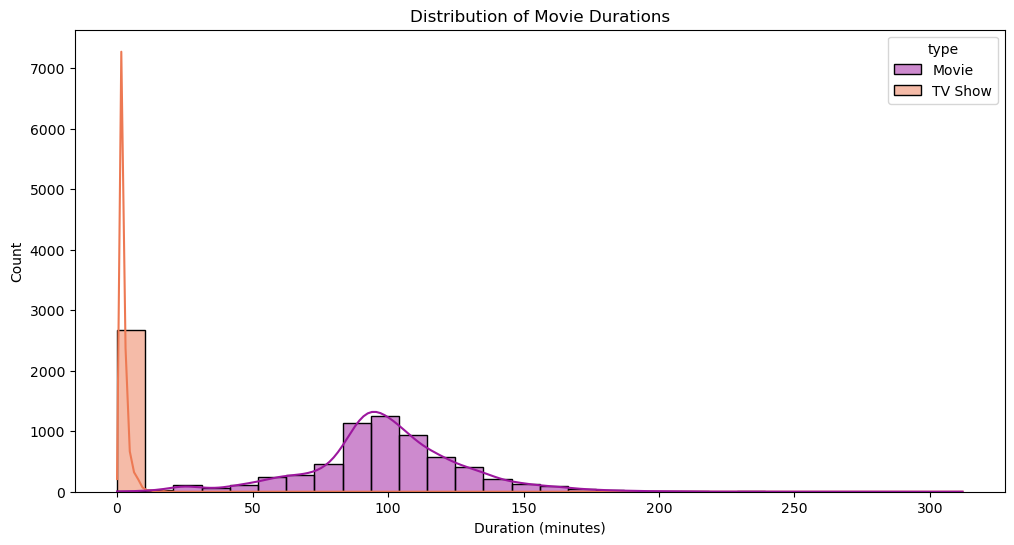

In [13]:
# Content Analysis - Duration Trends
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration_num', bins=30, kde=True, hue='type', palette='plasma')
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

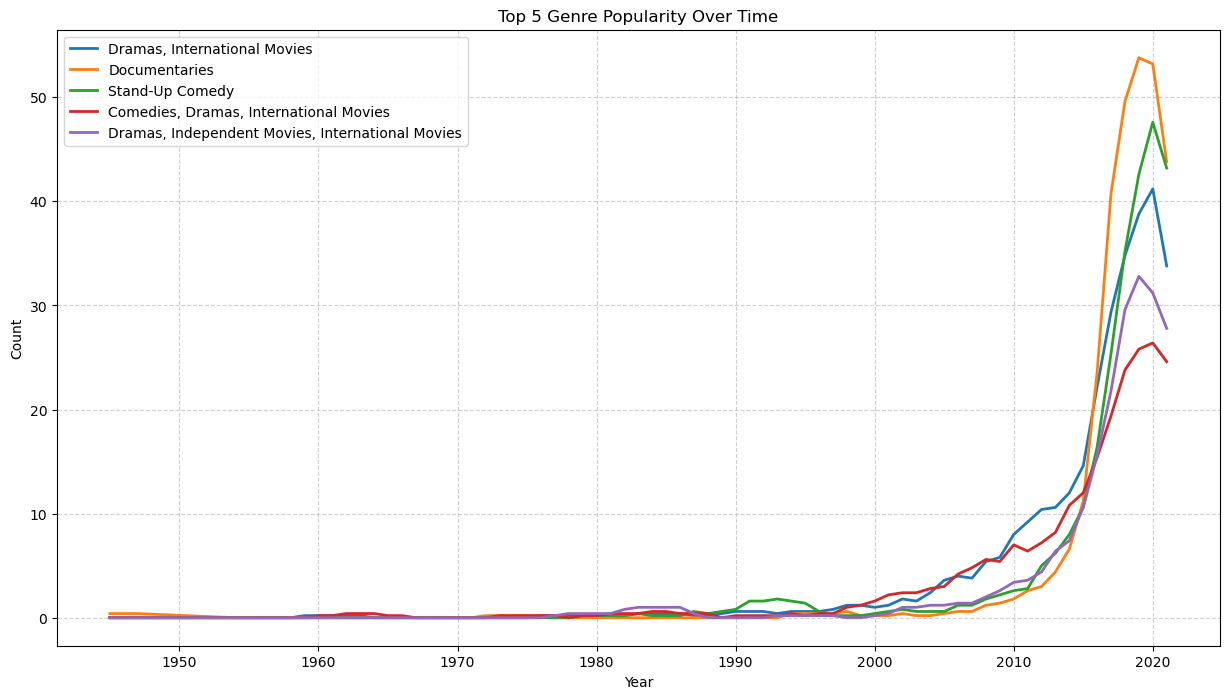

In [14]:
# Genre Trends Over Time
df['listed_in'] = df['listed_in'].astype(str)
df_genres = df.explode('listed_in')
genre_trends = df_genres.groupby(['release_year', 'listed_in']).size().unstack().fillna(0)
top_genres = genre_trends.sum().sort_values(ascending=False).head(5).index
genre_trends = genre_trends[top_genres]
plt.figure(figsize=(15, 8))
for genre in top_genres:
    plt.plot(genre_trends.index, genre_trends[genre].rolling(window=5).mean(), label=genre, linewidth=2)
plt.title("Top 5 Genre Popularity Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

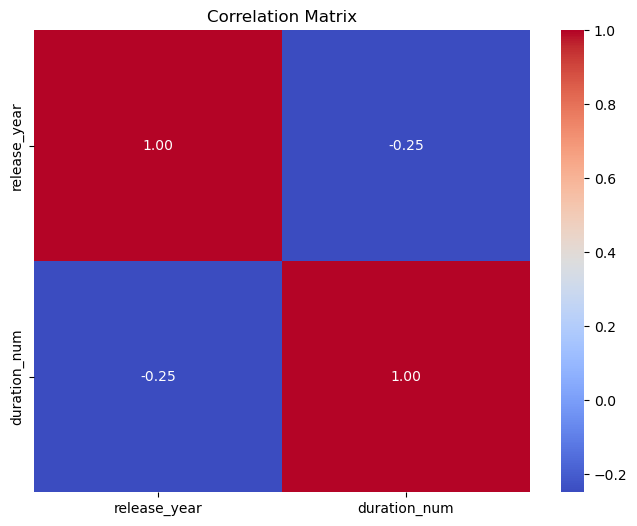

In [15]:
# Correlation Analysis
corr_matrix = df[['release_year', 'duration_num']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

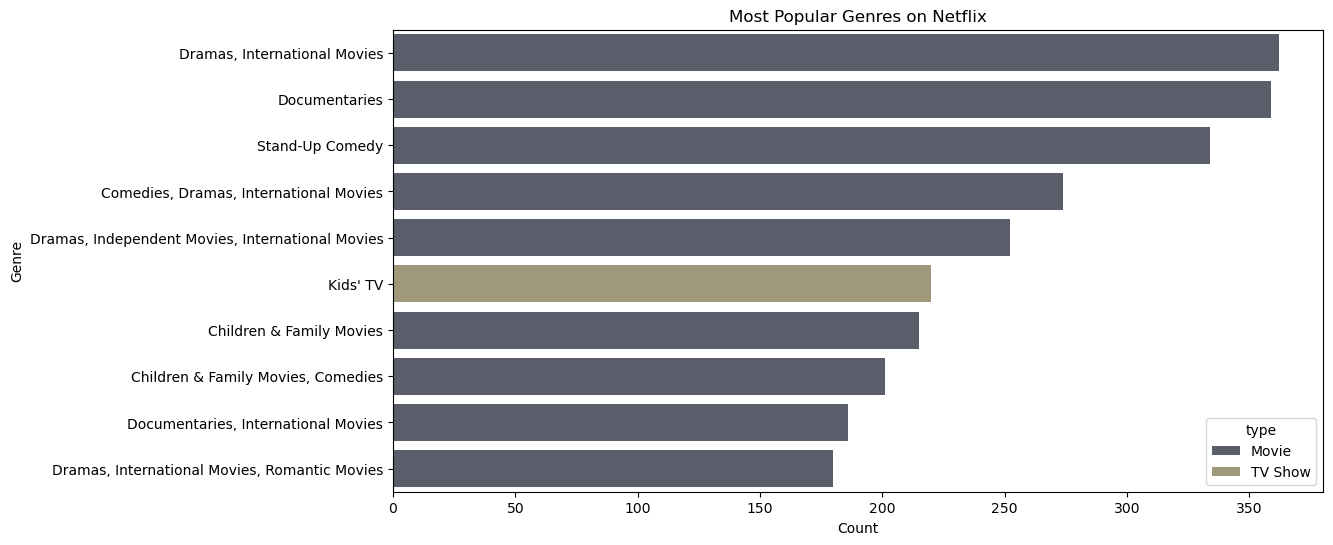

In [16]:
# User Preferences (Most Popular Genres)
plt.figure(figsize=(12, 6))
sns.countplot(y=df['listed_in'].explode(), order=df['listed_in'].explode().value_counts().index[:10], hue=df['type'], palette='cividis')
plt.title("Most Popular Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

## Conclusions
* "Key Findings:"
* "1. Netflix's content library is diverse, with strong representation from certain genres and countries."
* "2. The number of new titles added has varied significantly over time."
* "3. The duration of movies shows a consistent pattern, with most movies between 80-120 minutes."
* "4. Different genres have risen and fallen in popularity over the years."